# Predicting Student Grades Using Linear Regression

This notebook demonstrates the process of predicting student grades based on various factors such as socioeconomic status, study habits, sleep patterns, and attendance. Using a linear regression model, we will explore the data, train the model, and evaluate its performance using common metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared.

## Installing Required Libraries
Use the following command to install all dependencies listed in the requirements.txt file.

In [20]:
#!pip install -r requirements.txt

In [21]:
import pandas as pd 
from sklearn.model_selection import train_test_split  
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import mean_squared_error, r2_score  
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

## Loading the Dataset
Read the dataset into a pandas DataFrame for analysis.

In [22]:
# Load the dataset 
data_path = 'data.csv'
df = pd.read_csv(data_path)
df.head()

,Socioeconomic Score,Study Hours,Sleep Hours,Attendance (%),Grades
0,0.95822,3.4,8.2,53.0,47.0
1,0.85566,3.2,5.9,55.0,35.0
2,0.68025,3.2,9.3,41.0,32.0
3,0.25936,3.2,8.2,47.0,34.0
4,0.60447,3.8,10.0,75.0,33.0


## Selecting Features and Target Variable
Define the feature columns and the target variable for the analysis.

In [23]:
X = df[['Socioeconomic Score', 'Study Hours', 'Sleep Hours', 'Attendance (%)']] 
Y = df['Grades']

## Visualizing Feature and Target Distributions
Plot histograms to examine the distribution of features and the target variable.

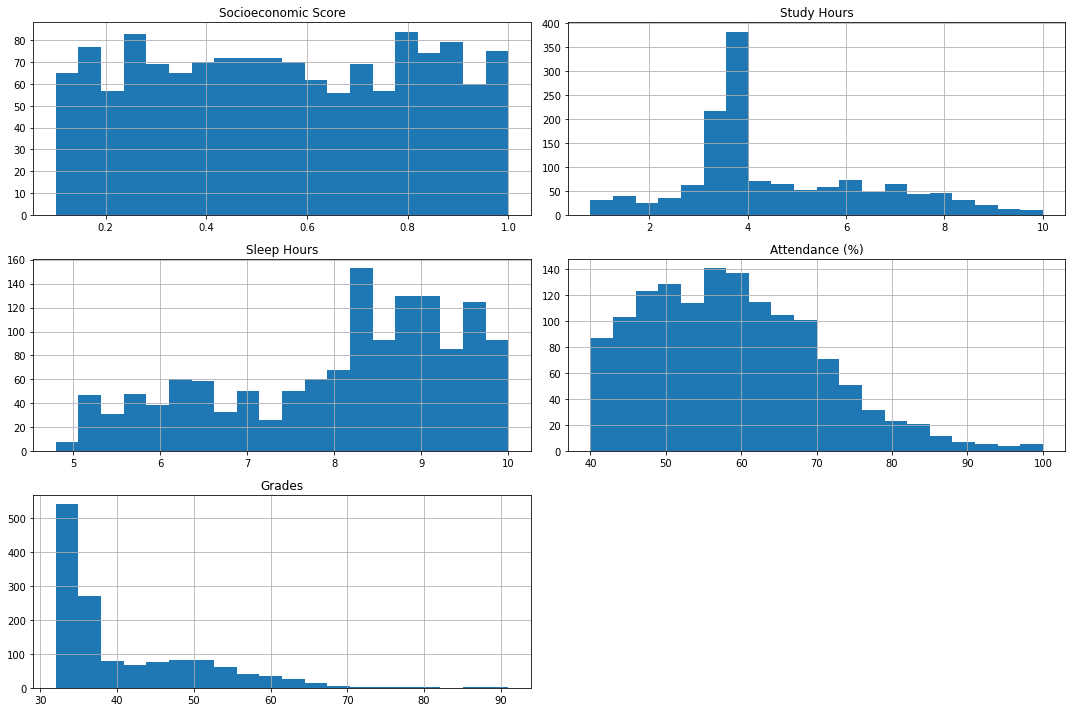

In [24]:
# Plot histograms for each feature and the target
df.hist(column=['Socioeconomic Score', 'Study Hours', 'Sleep Hours', 'Attendance (%)', 'Grades'], figsize=(15, 10), bins=20)
plt.tight_layout()
plt.savefig('histograms.png')
plt.show()

## Splitting the Dataset
Split the dataset into training and testing sets for model training and evaluation.

In [25]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## Training the Model
Create and train a linear regression model using the training data.

In [26]:
model = LinearRegression() 
model.fit(X_train, Y_train)

LinearRegression()

## Making Predictions
Use the trained model to predict grades for the test data.

In [27]:
Y_pred = model.predict(X_test)

## Evaluating the Model
Calculate and display key performance metrics for the regression model.

In [28]:
mse = mean_squared_error(Y_test, Y_pred) 
r2 = r2_score(Y_test, Y_pred) 
mae = mean_absolute_error(Y_test, Y_pred)
print(f"Mean Absolute Error: {mae}") 
print(f"Mean Squared Error: {mse}") 
print(f"R-squared: {r2}")

Mean Absolute Error: 3.386174501268349
Mean Squared Error: 19.272537728751253
R-squared: 0.7446674729714068


## Displaying Model Predictions and Errors
Create a DataFrame to display the actual values, predicted values, and the absolute error for each prediction. This provides a clear overview of the model's performance for individual data points.

In [29]:
# Create a DataFrame with Actual, Predicted, and Absolute Error
results_df = pd.DataFrame({
    "Actual": Y_test,
    "Predicted": Y_pred,
    "Absolute Error": abs(Y_test - Y_pred)
})

# Display the table
results_df


,Actual,Predicted,Absolute Error
650,43.0,44.007047,1.007047
208,35.0,35.001336,0.001336
427,33.0,35.678796,2.678796
677,36.0,36.444958,0.444958
1272,35.0,37.309276,2.309276
...,...,...,...
1061,37.0,41.843776,4.843776
339,34.0,34.565656,0.565656
1269,35.0,35.823526,0.823526
1311,33.0,31.570930,1.429070


## Actual vs. Predicted Values Scatter Plot (with Ideal Line)
The scatter plot shows the relationship between actual and predicted values, and the ideal line provides a visual reference for perfect predictions.

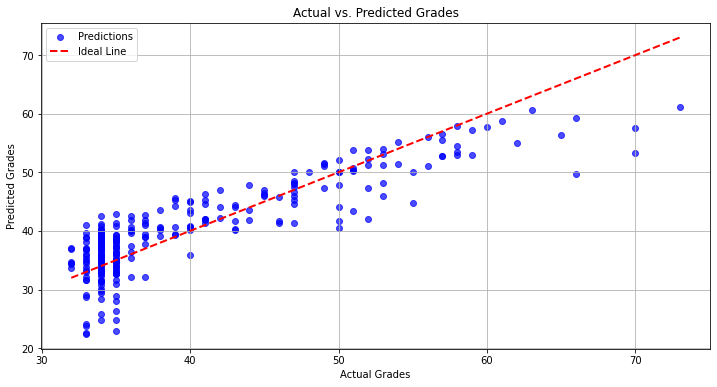

In [30]:
plt.figure(figsize=(12, 6))
plt.scatter(Y_test, Y_pred, alpha=0.7, color='blue', label="Predictions")
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--', linewidth=2, label="Ideal Line")
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Actual vs. Predicted Grades")
plt.legend()
plt.grid(True)
plt.savefig('actual_vs_predicted.png')
plt.show()